In [1]:
from shapely.geometry import Polygon
from pyproj import Geod
import math
import scipy
from matplotlib.path import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.colors as mcolors

In [2]:
def dx(ym, xm, f):
    dxm = np.abs(xm[0, 1] - xm[0, 0])
    der = (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2 * dxm)
    der[:, 0] = (f[:, 1] - f[:, -2]) / (2 * dxm)
    der[:, -1] = der[:, 0]
    return der

def dy(ym, xm, f):
    dym = np.abs(ym[1, 0] - ym[0, 0])
    der = (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2 * dym)
    der[0, :] = (f[1, :] - f[0, :]) / (dym)
    der[1, :] = (f[-1, :] - f[-2, :]) / (dym)
    return der

def ddy(ym, xm, f):
    dym = np.abs(ym[1, 0] - ym[0, 0])
    der = (np.roll(f, 1, axis=0) - 2 * f + np.roll(f, -1, axis=0)) / (dym ** 2)
    der[0, :] = der[1, :]
    der[-1, :] = der[-2, :]
    return der

def ddx(ym, xm, f):
    dxm = np.abs(xm[0, 1] - xm[0, 0])
    der = (np.roll(f, 1, axis=1) - 2 * f + np.roll(f, -1, axis=1)) / (dxm ** 2)
    der[:, 0] = (f[:, 1] - 2 * f[:, 0] + f[:, -2]) / (dxm ** 2)
    der[:, -1] = der[:, 0]
    return der

def ddxy(ym, xm, f):
    df_dx = dx(ym, xm, f)
    ddf_dxy = dy(ym, xm, df_dx)
    return ddf_dxy

def detH(ddx,ddy):
    derH=(ddx*ddy)
    return derH

def read_gauss_coeffs(filename, target_year, lmax=25):
  # Read Gauss coefficients for a specified year from a HISTKALMAG-format file.
  # The output Gauss coefficients gsh and hsh are ordered according to (l, m).
    with open(filename, 'r') as f:
        lines = f.readlines()

    years = list(map(float, lines[0].strip().split()))
    if target_year not in years:
        raise ValueError(f"No target_year {target_year}")
    idx = years.index(target_year)

    coeff_lines = lines[1:len(lines)]
    coeffs = [list(map(float, line.strip().split())) for line in coeff_lines]

    coeffs_at_year = [row[idx] for row in coeffs]
    gsh = []
    hsh = []
    i = 0
    for l in range(1, lmax + 1):
        for m in range(0, l + 1):
            if m == 0:
                gsh.append(coeffs_at_year[i])
                i+=1
                hsh.append(0.0)
            else:
                gsh.append(coeffs_at_year[i])
                i+=1
                hsh.append(coeffs_at_year[i])
                i += 1
    return np.array(gsh), np.array(hsh)

def magnetic_field(gsh,hsh,lmax,r,lats,lons):
    a=6371.2
    pi            = math.pi
    # lats          =  np.linspace(1., 179., num=181)
    # lons          =  np.linspace(-180., 180., num=181)
    lons2d,lats2d = np.meshgrid(lons,lats)
    phi           = lons2d
    cost2d        = np.cos((lats2d)*np.pi/180)
    i             = 0
    br            = np.zeros((cost2d.shape))
    bphi          = np.zeros((cost2d.shape))
    btheta        = np.zeros((cost2d.shape))
    for l in np.arange(1,lmax+1,1):
        for m in np.arange(0,l+1,1):
            g=gsh[i]
            h=hsh[i]
            #calculate schmidt
            if m  == 0:
                schmidt = 1.0
            else:
                schmidt = ((-1.0)**m)*np.sqrt(2.0*math.factorial(l-m)/math.factorial(l+m))
            lagendre     = scipy.special.lpmv(m, l, cost2d)
            lagendre_    = scipy.special.lpmv(m, l-1, cost2d)
            div_lagendre = (l*cost2d*lagendre-(l+m)*lagendre_)/np.sqrt(1-cost2d**2)
            br           = br     + schmidt*(float(l)+1.0)*((a/r)**(l+2))*lagendre*(g*np.cos(float(m)*phi*pi/180.0)
                                                                                    +h*np.sin(float(m)*phi*pi/180.0))
            bphi         = bphi   + schmidt*(m/np.sin((lats2d)*pi/180))*((a/r)**(l+2))*lagendre*(-g*np.sin(float(m)*phi*pi/180.0)
                                                                                                    +h*np.cos(float(m)*phi*pi/180.0))
            btheta       = btheta + schmidt*((a/r)**(l+2))*(div_lagendre)*(g*np.cos(float(m)*phi*pi/180.0)+h*np.sin(float(m)*phi*pi/180.0))
            i+=1
    return br,bphi,btheta,lons2d,lats2d

def calculate_integral(B):
    phi_range = np.linspace(0, 2 * np.pi, B.shape[1] + 1) 
    theta_range = np.linspace(0, np.pi, B.shape[0] + 1)  

    integrals = [0, 0]
    theta_min = np.deg2rad(25)
    theta_max = np.deg2rad(155)
    region_boundaries = [
        [(0, 2 * np.pi), (0, theta_min)],
        [(0, 2 * np.pi), (theta_max, np.pi)] ]
    for i, region in enumerate(region_boundaries):
        for j in range(len(phi_range) - 1):
            for k in range(len(theta_range) - 1):
                phi_lower = phi_range[j]
                phi_upper = phi_range[j + 1]
                theta_lower = theta_range[k]
                theta_upper = theta_range[k + 1]
                sin_theta = np.sin((theta_lower + theta_upper) / 2)
                d_phi = phi_upper - phi_lower
                d_theta = theta_upper - theta_lower

                if region[0][0] <= (phi_lower + phi_upper) / 2 <= region[0][1] and region[1][0] <= (theta_lower + theta_upper) / 2 <= region[1][1]:
                    integrals[i] += B[k, j] * sin_theta * d_phi * d_theta
    integral = sum(integrals)
    return integral

def F_C_ObO(x, y, fun1, fun2, lev): # main function to Find the Cross points one by one. 
    c_fx = plt.contour(x, y, fun1, levels=[lev])
    c_fy = plt.contour(x, y, fun2, levels=[lev])

    Line_dx = []
    points_dx = []
    paths = c_fx.get_paths()
    polygons = paths[0].to_polygons()

    for i, poly in enumerate(polygons):
        verts = poly
        if abs(verts[-1, 0] - verts[-2, 0]) > 10 or abs(verts[-1, 1] - verts[-2, 1]) > 10:
            zz = 2
        else:
            zz = 1
        points_dx.extend(verts)
        FxLine = []

        for v in range(len(verts) - zz):
            xa, ya = verts[v]
            xb, yb = verts[v + 1]
            xlist = np.array([xa, xb])
            ylist = np.array([ya, yb])

            # Skip if two points are too close (to avoid polyfit failure)
            if np.isclose(xa, xb) and np.isclose(ya, yb):
                continue

            try:
                k, b = np.polyfit([xa, xb], [ya, yb], deg=1)
            except np.linalg.LinAlgError:
                print(f"Warning: polyfit failed for points ({xa}, {ya}) - ({xb}, {yb}), skipped.")
                continue

            k, b = np.polyfit(xlist, ylist, deg=1)
            FxLine.append([k, b, xa, xb, ya, yb])

        Line_dx.append(np.array(FxLine))

    Line_dy = []
    points_dy = []
    paths = c_fy.get_paths()
    polygons = paths[0].to_polygons()

    for i, poly in enumerate(polygons):
        verts = poly
        if abs(verts[-1, 0] - verts[-2, 0]) > 10 or abs(verts[-1, 1] - verts[-2, 1]) > 10:
            zz = 2
        else:
            zz = 1
        points_dy.extend(verts)
        FyLine = []

        for v in range(len(verts) - zz):
            xa, ya = verts[v]
            xb, yb = verts[v + 1]
            xlist = np.array([xa, xb])
            ylist = np.array([ya, yb])

            # Skip if two points are too close (to avoid polyfit failure)
            if np.isclose(xa, xb) and np.isclose(ya, yb):
                continue

            try:
                k, b = np.polyfit([xa, xb], [ya, yb], deg=1)
            except np.linalg.LinAlgError:
                print(f"Warning: polyfit failed for points ({xa}, {ya}) - ({xb}, {yb}), skipped.")
                continue

            k, b = np.polyfit(xlist, ylist, deg=1)
            FyLine.append([k, b, xa, xb, ya, yb])

        Line_dy.append(np.array(FyLine))

    x_cross = []
    y_cross = []

    for n in range(len(Line_dx)):
        Fx = Line_dx[n]
        for m in range(len(Line_dy)):
            Fy = Line_dy[m]
            for p in range(len(Fx[:, 0])):
                k1, b1, x1, x2, y1, y2 = Fx[p, :]
                for q in range(len(Fy[:, 0])):
                    k2, b2, x3, x4, y3, y4 = Fy[q, :]
                    x_c = (b2 - b1) / (k1 - k2)
                    if x_c is not None:
                        # Check if x_c is within the x-range of both line segments
                        in_range_1 = (min(x1, x2) <= x_c <= max(x1, x2))
                        in_range_2 = (min(x3, x4) <= x_c <= max(x3, x4))
                        if in_range_1 and in_range_2:
                            y_c = k1 * x_c + b1
                            if y_c is not None:
                                # Check if y_c is within the y-range of both line segments
                                in_range_3 = (min(y1, y2) <= y_c <= max(y1, y2))
                                in_range_4 = (min(y3, y4) <= y_c <= max(y3, y4))
                                if in_range_3 and in_range_4:
                                    x_cross.append(x_c)
                                    y_cross.append(y_c)

    x_cross = np.array(x_cross)
    y_cross = np.array(y_cross)

    # Keep only points with y in [5, 175]
    mask = (y_cross >= 5) & (y_cross <= 175)
    x_cross = x_cross[mask]
    y_cross = y_cross[mask]

    return x_cross, y_cross

def detH_saddle(DETH, thetam, phim, crossingsX,crossingsY):

    lat_grid = thetam[:, 0]
    lon_grid = phim[0, :]

    interp_func = scipy.interpolate.RegularGridInterpolator((lat_grid, lon_grid), DETH,
                                                            bounds_error=False,
                                                            fill_value=np.nan)
    cross = np.column_stack((crossingsX, crossingsY))
    cross = np.array(cross)
    points_for_interp = cross[:, [1, 0]]
    values = interp_func(points_for_interp)

    pos_mask = values > 0
    neg_mask = values <= 0

    pos_points = points_for_interp[pos_mask]
    neg_points = points_for_interp[neg_mask]

    return pos_points, neg_points

def magnetic_point(gsh, hsh, lmax, r, y, x):
    fi=[]
    for i in range(0,len(y)):
        br,bphi,btheta,_,_=magnetic_field(gsh, hsh, lmax, radius, y[i], x[i])
        fff=np.sqrt(br**2 + bphi**2 + btheta**2)/1000
        fi.append(fff)
    return np.array(fi).squeeze()

In [5]:
def num_conter(in_F, in_level):  # Count the number of independent regions
    c_fs = plt.contour(phi, theta, in_F, levels=in_level)
    paths2 = c_fs.get_paths()
    polygons2 = paths2[0].to_polygons()

    nn = 0
    zz = 0

    for poly in polygons2:
        lat_line = poly[:, 1]
        lon_line = poly[:, 0]

        if (np.isclose(poly[0, 0], 360.0) and np.isclose(poly[-1, 0], 360.0)) \
                or (np.isclose(poly[0, 0], 0.0) and np.isclose(poly[-1, 0], 0.0)):
            zz = 1 + zz
        else:
            nn = nn + 1

        plt.plot(poly[:, 0], poly[:, 1])

    Num = nn + (zz / 2)
    return Num


def AREA(lats_fo, lons_fo):  # Boundary lat/lon; lats_fo must already be 90 - lat
    geod = Geod(ellps="WGS84")
    polygon = Polygon(zip(lons_fo, lats_fo))
    area_fo, _ = geod.geometry_area_perimeter(polygon)
    area_km2_fo = abs(area_fo) / 1e6
    return area_km2_fo


def all_area(polygons2):
    total_area_add = 0.0  # Total area to be merged across the dateline
    areas_not_add = []

    nn = 0
    zz = 0

    for poly in polygons2:
        lat_line = 90 - poly[:, 1]
        lon_line = poly[:, 0]

        if (np.isclose(poly[0, 0], 360.0) and np.isclose(poly[-1, 0], 360.0)) \
                or (np.isclose(poly[0, 0], 0.0) and np.isclose(poly[-1, 0], 0.0)):
            zz = 1 + zz
            area_need_add = AREA(lat_line, lon_line)
            total_area_add += area_need_add
        else:
            nn = nn + 1
            area_not_add = AREA(lat_line, lon_line)
            areas_not_add.append(area_not_add)

        plt.plot(poly[:, 0], poly[:, 1])

    if zz > 1:
        areas_not_add.append(total_area_add)

    print(areas_not_add)

    Num = nn + (zz / 2)
    print("Number of regions after merging:", Num)

    return np.array(areas_not_add)


def collect_inside(lats_fo, lons_fo, thetam, phim):  # Collect points inside each region; merge later if needed
    lat_grid = 90 - thetam
    lon_grid = phim
    theta_grid = thetam

    polygon_path = Path(np.vstack([lons_fo, lats_fo]).T)
    grid_points = np.vstack([lon_grid.ravel(), lat_grid.ravel()]).T

    inside = polygon_path.contains_points(grid_points)
    if not np.any(inside):
        return np.array([]), np.array([]), np.array([])

    phi_in = grid_points[inside, 0]
    theta_in = theta_grid.ravel()[inside]
    F_in = F.ravel()[inside]

    return phi_in, theta_in, F_in


def CenterOfMass(All_phi_inside, All_theta_inside, All_F_inside):
    w_sum = (1 / All_F_inside)
    w_sin = np.sin(All_theta_inside * np.pi / 180)

    phi_cm_Fc = np.sum(All_phi_inside * w_sum * w_sin) / np.sum(w_sum * w_sin)
    phi_cm_Fc = phi_cm_Fc % 360

    theta_cm_Fc = np.sum(All_theta_inside * w_sin * w_sum) / np.sum(w_sum * w_sin)
    return theta_cm_Fc, phi_cm_Fc


def all_center(polygons2):
    inside_add_phi = []
    inside_add_theta = []
    inside_add_F = []

    theta_output = []
    phi_output = []

    nn = 0
    zz = 0

    for poly in polygons2:
        lat_line = 90 - poly[:, 1]
        lon_line = poly[:, 0]

        if (np.isclose(poly[0, 0], 360.0) and np.isclose(poly[-1, 0], 360.0)) \
                or (np.isclose(poly[0, 0], 0.0) and np.isclose(poly[-1, 0], 0.0)):
            zz = 1 + zz

            phi_in, theta_in, F_in = collect_inside(lat_line, lon_line, thetam, phim)
            inside_add_phi.append(phi_in)
            inside_add_theta.append(theta_in)
            inside_add_F.append(F_in)
        else:
            nn = nn + 1

            phi_in, theta_in, F_in = collect_inside(lat_line, lon_line, thetam, phim)
            theta_CM, phi_CM = CenterOfMass(phi_in, theta_in, F_in)
            theta_output.append(theta_CM)
            phi_output.append(phi_CM)

        plt.plot(poly[:, 0], poly[:, 1])

    if zz > 1:
        inside_add_phi = np.concatenate(inside_add_phi)
        inside_add_theta = np.concatenate(inside_add_theta)
        inside_add_F = np.concatenate(inside_add_F)
        inside_add_phi = ((inside_add_phi + 180) % 360) - 180

        theta_CM, phi_CM = CenterOfMass(
            np.array(inside_add_phi),
            np.array(inside_add_theta),
            np.array(inside_add_F),
        )
        theta_output.append(theta_CM)
        phi_output.append(phi_CM)

    print(theta_output, phi_output)

    Num = nn + (zz / 2)
    print("Number of regions after merging:", Num)

    return phi_output, theta_output


def selecte(F_S, Fc):
    mask_S = F_S < Fc
    F_S_selected = F_S[mask_S]
    return F_S_selected


In [7]:
cmap="RdGy"
linecolor="forestgreen"
vmin = 20
vmax = 70

fontweight='bold'
fontname='Arial'
fontsize=14
markersize = 70
SaddleColor="k"
SaddleMarker="o"
ExtremaColor="white"
ExtremaMarker="^"

massmarker_Fs="+"
massmarker="x"
masscolor="forestgreen"
masssize=60

In [9]:
radius = 6371.
theta = np.linspace(1., 179., num=181)  # colatitude in degrees
phi = np.linspace(0., 360., num=361)  # longitude in degrees
phim, thetam = np.meshgrid(phi, theta)
radiusm = radius * np.ones(phim.shape)
filepath="D:\\work\\origin data\\coeff\\HistKalmag.txt"

lmax=20
r=6371
n=1
gsh, hsh = read_gauss_coeffs(filepath, 1950, lmax=lmax)
br,bphi,btheta,lons2d,lats2d=magnetic_field(gsh, hsh, lmax, radius, theta, phi)
F1950=np.sqrt(br**2 + bphi**2 + btheta**2)/1000
Fo1950=calculate_integral(F1950)

Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[68663514.88362518]
Number of regions after merging: 1.0
[97.9692011049567] [85.22474038627632]
Number of regions after merging: 1.0
Final number of partitioned areas: 1
[1.]
[97.9692011049567] [85.22474038627632]
Number of regions after merging: 1.0
[68663514.88362518]
Number of regions after merging: 1.0


C:\Users\82079\AppData\Local\Temp\ipykernel_43644\1922645594.py:77: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  paths2 = c_fs.collections[0].get_paths()
C:\Users\82079\AppData\Local\Temp\ipykernel_43644\1922645594.py:174: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  paths2 = c_fc.collections[0].get_paths()


Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[68365251.65105984]
Number of regions after merging: 1.0
[98.05500166852654] [84.27724061766335]
Number of regions after merging: 1.0
Final number of partitioned areas: 1
[1.]
[98.05500166852654] [84.27724061766335]
Number of regions after merging: 1.0
[68365251.65105984]
Number of regions after merging: 1.0
Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[68126820.96320976]
Number of regions after merging: 1.0
[98.06305911397615] [83.21650597136957]
Number of regions after merging: 1.0
Final number of partitioned areas: 1
[1.]
[98.06305911397615] [83.21650597136957]
Number of regions after merging: 1.0
[68126820.96320976]
Number of regions after merging: 1.0
Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[67968967.8824234]
Number of regions after merging: 1.0
[98.10788296459525] [82.04987956681269]
Number of regions after merging: 1.0
Final number of partit

C:\Users\82079\AppData\Local\Temp\ipykernel_43644\1922645594.py:90: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  paths2 = c_fs.collections[0].get_paths()


[97.82157678651946] [74.11064513051032]
Number of regions after merging: 1.0
[1, 0] [0.01708221 0.98291779]
Final number of partitioned areas: 2
[0.98291779 0.01708221]
[97.82157678651946] [74.11064513051032]
Number of regions after merging: 1.0
[69221354.83308473]
Number of regions after merging: 1.0
Number of E and S points within the region: 2 1
Number of sub-regions: 2.0
[1768100.7886076006, 53862033.070047684]
Number of regions after merging: 2.0
[83.80423076084018, 99.62448316262082] [341.2620914601907, 82.2034629078556]
Number of regions after merging: 2.0
[70363339.20900288]
Number of regions after merging: 1.0
[97.67045058530631] [71.85374364968524]
Number of regions after merging: 1.0
[0, 1] [0.03178315 0.96821685]
Final number of partitioned areas: 2
[0.03178315 0.96821685]
[97.67045058530631] [71.85374364968524]
Number of regions after merging: 1.0
[70363339.20900288]
Number of regions after merging: 1.0
Number of E and S points within the region: 2 1
Number of sub-regions:

...

Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[51700437.539197594]
Number of regions after merging: 1.0
[102.79762770968819] [353.76148006114005]
Number of regions after merging: 1.0
Final number of partitioned areas: 1
[1.]
[102.79762770968819] [353.76148006114005]
Number of regions after merging: 1.0
[51700437.539197594]
Number of regions after merging: 1.0


C:\Users\82079\AppData\Local\Temp\ipykernel_43644\3571805891.py:191: RankWarning: Polyfit may be poorly conditioned
  k, b = np.polyfit([xa, xb], [ya, yb], deg=1)
C:\Users\82079\AppData\Local\Temp\ipykernel_43644\3571805891.py:196: RankWarning: Polyfit may be poorly conditioned
  k, b = np.polyfit(xlist, ylist, deg=1)


Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[52360534.91133197]
Number of regions after merging: 1.0
[102.79908805228855] [352.78907677683264]
Number of regions after merging: 1.0
Final number of partitioned areas: 1
[1.]
[102.79908805228855] [352.78907677683264]
Number of regions after merging: 1.0
[52360534.91133197]
Number of regions after merging: 1.0


C:\Users\82079\AppData\Local\Temp\ipykernel_43644\3571805891.py:191: RankWarning: Polyfit may be poorly conditioned
  k, b = np.polyfit([xa, xb], [ya, yb], deg=1)
C:\Users\82079\AppData\Local\Temp\ipykernel_43644\3571805891.py:196: RankWarning: Polyfit may be poorly conditioned
  k, b = np.polyfit(xlist, ylist, deg=1)


Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[51576241.33724572]
Number of regions after merging: 1.0
[103.06194518075782] [351.1709325839489]
Number of regions after merging: 1.0
Final number of partitioned areas: 1
[1.]
[103.06194518075782] [351.1709325839489]
Number of regions after merging: 1.0
[51576241.33724572]
Number of regions after merging: 1.0
Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[50889197.28702308]
Number of regions after merging: 1.0
[103.33455983814792] [349.5691698240165]
Number of regions after merging: 1.0
Final number of partitioned areas: 1
[1.]
[103.33455983814792] [349.5691698240165]
Number of regions after merging: 1.0
[50889197.28702308]
Number of regions after merging: 1.0
Number of E and S points within the region: 1 0
Number of sub-regions: 1.0
[50739208.08107928]
Number of regions after merging: 1.0
[103.68063285080927] [347.4628845691059]
Number of regions after merging: 1.0
Final number of 

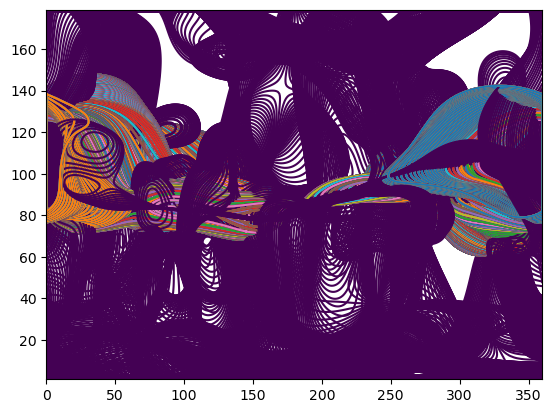

In [15]:
radius = 6371.0
theta = np.linspace(1.0, 179.0, num=181)  # colatitude in degrees
phi = np.linspace(0.0, 360.0, num=361)  # longitude in degrees; update interval if needed
phim, thetam = np.meshgrid(phi, theta)
radiusm = radius * np.ones(phim.shape)
filepath = r"D:\work\origin data\coeff\HistKalmag.txt"  #Replace

lmax = 20
r = 6371
n = 1

finaly_sub_area = []
finaly_cm_phi = []
finaly_cm_theta = []
years_E = []
year_all = []
F_E_all = []
Ftotal = []
Ftotal_year = []
finaly_cm_phi_fc = []
finaly_cm_theta_fc = []
year_fc_cm = []
Phi_E_all = []
Theta_E_all = []s

for year in range(1000, 1955, 5): #replace time-steps
    yr = year
    gsh, hsh = read_gauss_coeffs(filepath, yr, lmax=lmax)
    br, bphi, btheta, lons2d, lats2d = magnetic_field(gsh, hsh, lmax, radius, theta, phi)
    F = np.sqrt(br**2 + bphi**2 + btheta**2) / 1000

    Fout = calculate_integral(F)
    Fc = 32 * (Fout / Fo1950)

    vcenter = Fc  # set this value to white in the colormap
    norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    F_real = F
    d_x = dx(thetam, phim, F_real)
    d_y = dy(thetam, phim, F_real)
    dd_x = ddx(thetam, phim, F_real)
    dd_y = ddy(thetam, phim, F_real)

    DETH = detH(dd_x, dd_y)
    crossingsX1, crossingsY1 = F_C_ObO(phi, theta, d_x, d_y, 0)
    E, S = detH_saddle(DETH, thetam, phim, crossingsX1, crossingsY1)
    H_S_lat, H_S_lon = S[:, 0], S[:, 1]
    H_E_lat, H_E_lon = E[:, 0], E[:, 1]

    F_S = magnetic_point(gsh, hsh, lmax, r, H_S_lat, H_S_lon)
    F_E = magnetic_point(gsh, hsh, lmax, r, H_E_lat, H_E_lon)

    mask_S = F_S < Fc
    F_S_selected = np.array(F_S[mask_S])
    lat_S_selected = np.array(H_S_lat[mask_S])
    lon_S_selected = np.array(H_S_lon[mask_S])

    sort_idx = np.argsort(F_S_selected)
    F_S_selected = F_S_selected[sort_idx]
    lat_S_selected = lat_S_selected[sort_idx]
    lon_S_selected = lon_S_selected[sort_idx]

    mask_E = F_E < Fc
    F_E_selected = np.array(F_E[mask_E])
    lat_E_selected = np.array(H_E_lat[mask_E])
    lon_E_selected = np.array(H_E_lon[mask_E])

    print("Number of E and S points within the region:", len(F_E_selected), len(F_S_selected))

    Num_Fc = num_conter(F, [Fc])
    region_number = Num_Fc + len(F_S_selected)
    print("Number of sub-regions:", region_number)

    F_b = np.concatenate([F_S_selected, np.array([(Fc / 0.999)])])

    c_fs = plt.contour(phi, theta, F, levels=[0.999 * F_b[0]])
    paths2 = c_fs.collections[0].get_paths()
    polygons2 = paths2[0].to_polygons()
    area_s1 = all_area(polygons2)
    cm_phi_s1, cm_theta_s1 = all_center(polygons2)

    Asub = []
    for r in range(0, len(area_s1)):
        Asub.append(area_s1[r] / (np.sum(area_s1)))
    Asub = np.array(Asub)

    if len(F_b) > 0:
        for o in range(1, len(F_b)):
            c_fs = plt.contour(phi, theta, F, levels=[0.999 * F_b[o]])
            paths2 = c_fs.collections[0].get_paths()
            polygons2 = paths2[0].to_polygons()
            area_s2 = all_area(polygons2)
            cm_phi_s2, cm_theta_s2 = all_center(polygons2)

            cm_location = np.column_stack([cm_phi_s1, cm_theta_s1])
            markNo = []
            mark = []
            addNO = []
            marker = 0
            zz = 0
            nn = 0
            mm = 0

            for poly in polygons2:
                lat_line = 90 - poly[:, 1]
                lon_line = poly[:, 0]
                sad_location = np.column_stack([cm_phi_s1, cm_theta_s1])

                if (np.isclose(poly[0, 0], 360.0) and np.isclose(poly[-1, 0], 360.0)) or (np.isclose(poly[0, 0], 0.0) and np.isclose(poly[-1, 0], 0.0)):
                    zz = 1 + zz
                    mm = 1
                    polygon_path = Path(np.vstack([lon_line, poly[:, 1]]).T)
                    inside = polygon_path.contains_points(sad_location)
                    if np.any(inside):
                        marker = 1
                    polygon_path_s = Path(np.vstack([lon_line, poly[:, 1]]).T)
                    inside_array_s = polygon_path.contains_points(cm_location)
                    indices_inside = np.where(inside_array_s)[0]
                    addNO.extend(indices_inside)
                else:
                    nn = nn + 1
                    polygon_path = Path(np.vstack([lon_line, poly[:, 1]]).T)
                    inside = polygon_path.contains_points(sad_location)
                    mark.append(np.any(inside))
                    polygon_path = Path(np.vstack([lon_line, poly[:, 1]]).T)
                    inside_array = polygon_path.contains_points(cm_location)
                    indices_inside = np.where(inside_array)[0]
                    markNo.append(indices_inside)

            if marker == 1:  # merged interval exists
                mark.append(True)
                markNo.append(addNO)
            elif marker != 1 and mm == 0:  # no merged interval; skip
                pass
            elif marker != 1 and mm == 1:  # no merged interval, but mm = 1
                mark.append(False)

            mark = np.array(mark)
            area_sub = np.zeros_like(Asub, dtype=float)

            for i, idxs in enumerate(markNo):
                if len(idxs) > 0:
                    weights = Asub[idxs]
                    print(idxs, weights)
                    area_sub[idxs] = area_s2[i] * weights / np.sum(weights)

            cm_phi_s2 = np.array(cm_phi_s2)
            cm_theta_s2 = np.array(cm_theta_s2)

            empty_idx = [i for i in range(len(markNo)) if len(markNo[i]) == 0]
            empty_area = area_s2[empty_idx]
            empty_phi = cm_phi_s2[empty_idx]
            empty_theta = cm_theta_s2[empty_idx]

            new_cm_phi = []
            new_cm_theta = []

            area_sub = np.concatenate([area_sub, empty_area])
            new_cm_phi = np.concatenate([cm_phi_s1, empty_phi])
            new_cm_theta = np.concatenate([cm_theta_s1, empty_theta])

            Asub_new = []
            for r in range(0, len(area_sub)):
                Asub_new.append(area_sub[r] / (np.sum(area_sub)))

            Asub = np.array(Asub_new)
            cm_phi_s1 = np.array(new_cm_phi)
            cm_theta_s1 = np.array(new_cm_theta)

    print("Final number of partitioned areas:", len(Asub))
    print(Asub)

    c_fc = plt.contour(phi, theta, F, levels=[Fc])
    paths2 = c_fc.collections[0].get_paths()
    polygons2 = paths2[0].to_polygons()
    cm_phi_fc, cm_theta_fc = all_center(polygons2)
    ar = all_area(polygons2)
    save_area = np.sum(ar) * Asub

    Ftotal.append(np.sum(ar))
    Ftotal_year.append(year)

    years_E.extend([yr] * len(F_E_selected))
    F_E_all.extend(F_E_selected)
    Phi_E_all.extend(lon_E_selected)
    Theta_E_all.extend(lat_E_selected)

    finaly_sub_area.extend(save_area)
    finaly_cm_phi.extend(cm_phi_s1)
    finaly_cm_theta.extend(cm_theta_s1)
    year_all.extend([yr] * len(cm_theta_s1))

    finaly_cm_phi_fc.extend(cm_phi_fc)
    finaly_cm_theta_fc.extend(cm_theta_fc)
    year_fc_cm.extend([yr] * len(cm_theta_fc))


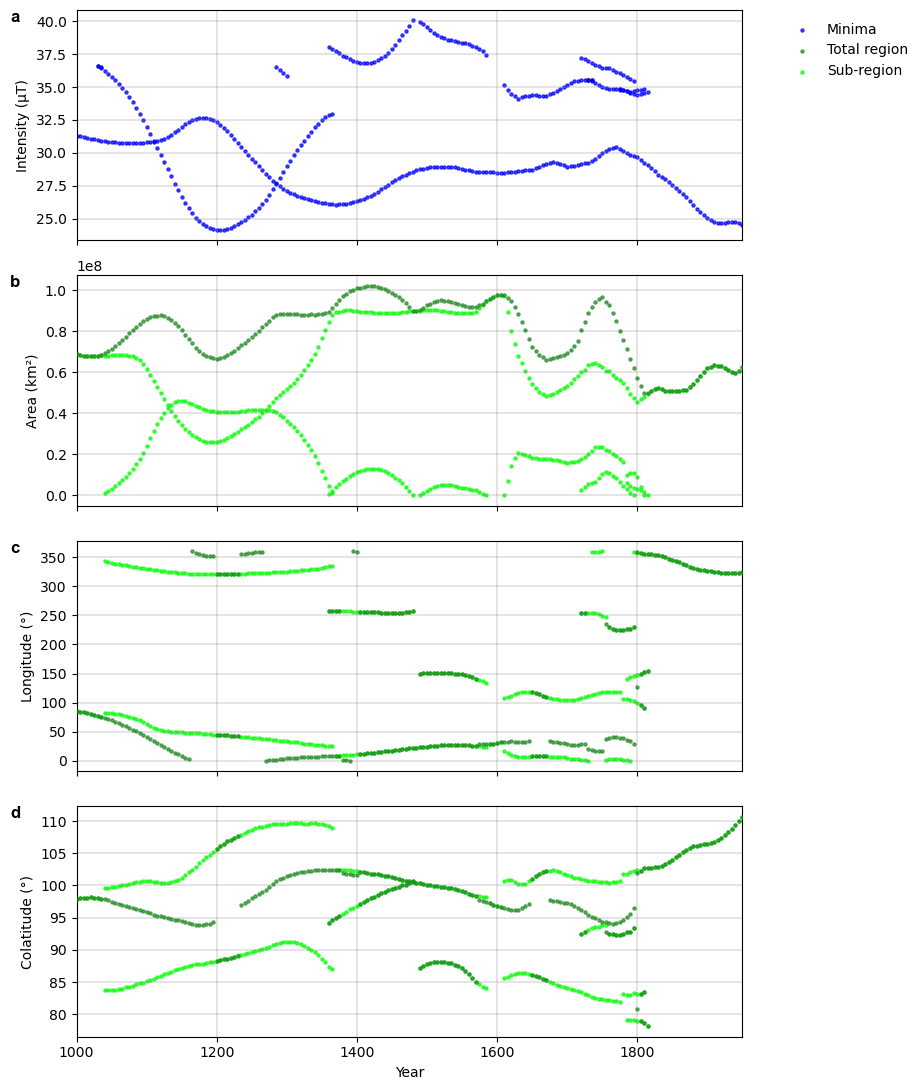

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

fig, axs = plt.subplots(4, 1, figsize=(10, 11))

marker_size = 20
subregionCMcolor = "lime"

# Panel a: Magnetic intensity vs year
axs[0].scatter(years_E, F_E_all, label="Minima", color="blue", marker=".", s=marker_size, alpha=0.7)
axs[0].set_ylabel("Intensity (μT)")
axs[0].set_xlim(1000, 1950)

# Panel b: Area vs year
axs[1].scatter(Ftotal_year, Ftotal, label=r"$A_{total}$", color="forestgreen", marker=".", alpha=0.7, s=marker_size, zorder=5)
axs[1].scatter(year_all, finaly_sub_area, label=r"$A_{sub}$", color=subregionCMcolor, marker=".", alpha=0.7, s=marker_size)
axs[1].set_ylabel("Area (km²)")
axs[1].set_xlim(1000, 1950)

# Panel c: Longitude vs year
axs[2].scatter(year_fc_cm, finaly_cm_phi_fc, label=r"$CM$ of $A_{total}$", s=marker_size, alpha=0.7, color="forestgreen", marker=".", zorder=5)
axs[2].scatter(year_all, finaly_cm_phi, label=r"$CM$ of $A_{sub}$", s=marker_size, alpha=0.7, color=subregionCMcolor, marker=".")
axs[2].set_ylabel("Longitude (°)")
axs[2].set_xlim(1000, 1950)

# Panel d: Colatitude vs year
axs[3].scatter(year_fc_cm, finaly_cm_theta_fc, label="Total region", s=marker_size, alpha=0.7, color="forestgreen", marker=".", zorder=5)
axs[3].scatter(year_all, finaly_cm_theta, label="Sub-region", s=marker_size, alpha=0.7, color=subregionCMcolor, marker=".")
axs[3].set_xlabel("Year")
axs[3].set_ylabel("Colatitude (°)")
axs[3].set_xlim(1000, 1950)

for ax in axs:
    ax.grid(True, which="both", color="gray", linestyle="-", linewidth=0.3)

axs[0].text(-0.10, 1, "a", transform=axs[0].transAxes, fontsize=12, fontweight="bold", fontfamily="Arial", color="black", va="top", ha="left")
axs[1].text(-0.10, 1, "b", transform=axs[1].transAxes, fontsize=12, fontweight="bold", fontfamily="Arial", color="black", va="top", ha="left")
axs[2].text(-0.10, 1, "c", transform=axs[2].transAxes, fontsize=12, fontweight="bold", fontfamily="Arial", color="black", va="top", ha="left")
axs[3].text(-0.10, 1, "d", transform=axs[3].transAxes, fontsize=12, fontweight="bold", fontfamily="Arial", color="black", va="top", ha="left")

axs[0].set_xticklabels([])
axs[1].set_xticklabels([])
axs[2].set_xticklabels([])

handles1, labels1 = axs[0].get_legend_handles_labels()
handles4, labels4 = axs[3].get_legend_handles_labels()
handles = handles1 + handles4
labels = labels1 + labels4

axs[0].legend(handles, labels, loc="upper left", bbox_to_anchor=(1.05, 1.0), frameon=False)

plt.subplots_adjust(hspace=0.1)
plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()
